In [1]:
import joblib
import os
import numpy as np
from PIL import Image
import time
import gc
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random

import tensorflow as tf
from tensorflow.keras import layers
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from collections import defaultdict

device_name = tf.test.gpu_device_name()
if "GPU" not in device_name:
    print("GPU device not found")
print('Found GPU at: {}'.format(device_name))

2025-07-28 17:19:56.343763: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1753723196.524664      19 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1753723196.578763      19 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


Found GPU at: /device:GPU:0


I0000 00:00:1753723208.857596      19 gpu_device.cc:2022] Created device /device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [2]:
def load_pickles(pickle_dir, image_size):
    pickle_data = {}

    pickles = [
        "training_images-002", "training_labels",
        "verification_images", "verification_labels"
    ]

    for pickle in pickles:
        filename = f"{pickle}.pkl"
        file_path = os.path.join(pickle_dir, filename)
        if os.path.exists(file_path):
            print(f"Loading {file_path}")
            with open(file_path, "rb") as f:
                pickle_data[pickle] = joblib.load(f)
        else:
            print(f"Warning: {filename} not found in {pickle_dir}")

    return (
        pickle_data.get("training_images-002"),
        pickle_data.get("training_labels"),
        pickle_data.get("verification_images"),
        pickle_data.get("verification_labels"),
    )

In [3]:
PICKLE_DIR = '/kaggle/input/assignment2-facerec/dataset'


IMAGE_SIZE = 64
IMAGE_DIMENSIONS = (IMAGE_SIZE, IMAGE_SIZE)
IMAGE_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, 3)

var_names = [
    "training_images", "training_labels",
    "verification_images", "verification_labels"
]
for var in var_names:
    if var in globals():
        del globals()[var]
        
gc.collect()
(training_images,
training_labels,
verification_images,
verification_labels) = load_pickles(PICKLE_DIR, IMAGE_SIZE)

Loading /kaggle/input/assignment2-facerec/dataset/training_images-002.pkl
Loading /kaggle/input/assignment2-facerec/dataset/training_labels.pkl
Loading /kaggle/input/assignment2-facerec/dataset/verification_images.pkl
Loading /kaggle/input/assignment2-facerec/dataset/verification_labels.pkl


In [4]:
training_labels_images = defaultdict(list)
for img, label in zip(training_images, training_labels):
    training_labels_images[label].append(img)

In [5]:
def create_triplets(images_dict, labels_list, max_images=5):
    triplets = []
    
    for label in labels_list:
        images = images_dict[label][:max_images]
        num_images = len(images)
        
        for i in range(num_images-1):
            for j in range(i+1, num_images):
                anchor = images[i]
                positive = images[j]

                neg_label = label
                while neg_label == label:
                    neg_label = random.choice(labels_list)
                neg_idx = random.randint(0, len(images_dict[neg_label])-1)
                neg_image = images_dict[neg_label][neg_idx]
                negative = neg_image

                triplets.append((anchor, positive, negative))
    random.shuffle(triplets)       
    return triplets

In [6]:
triplets = create_triplets(training_labels_images, np.unique(training_labels), max_images=10)

In [7]:
len(triplets)

180000

In [8]:
class TripletDataset(tf.keras.utils.Sequence):
    def __init__(self, dataset, batch_size=64):
        self.dataset = dataset
        self.batch_size = batch_size

    def __len__(self):
        return len(self.dataset) // self.batch_size

    def __getitem__(self, idx):
        start = idx * self.batch_size
        end = min((idx + 1) * self.batch_size, len(self.dataset))
        
        anchors   = []
        positives = []
        negatives = []
        
        for i in range(start, end):
            a, p, n = self.dataset[i]
            anchors.append(a)
            positives.append(p)
            negatives.append(n)

        return (
            (np.array(anchors), np.array(positives), np.array(negatives)),
            np.zeros((self.batch_size,))
        )

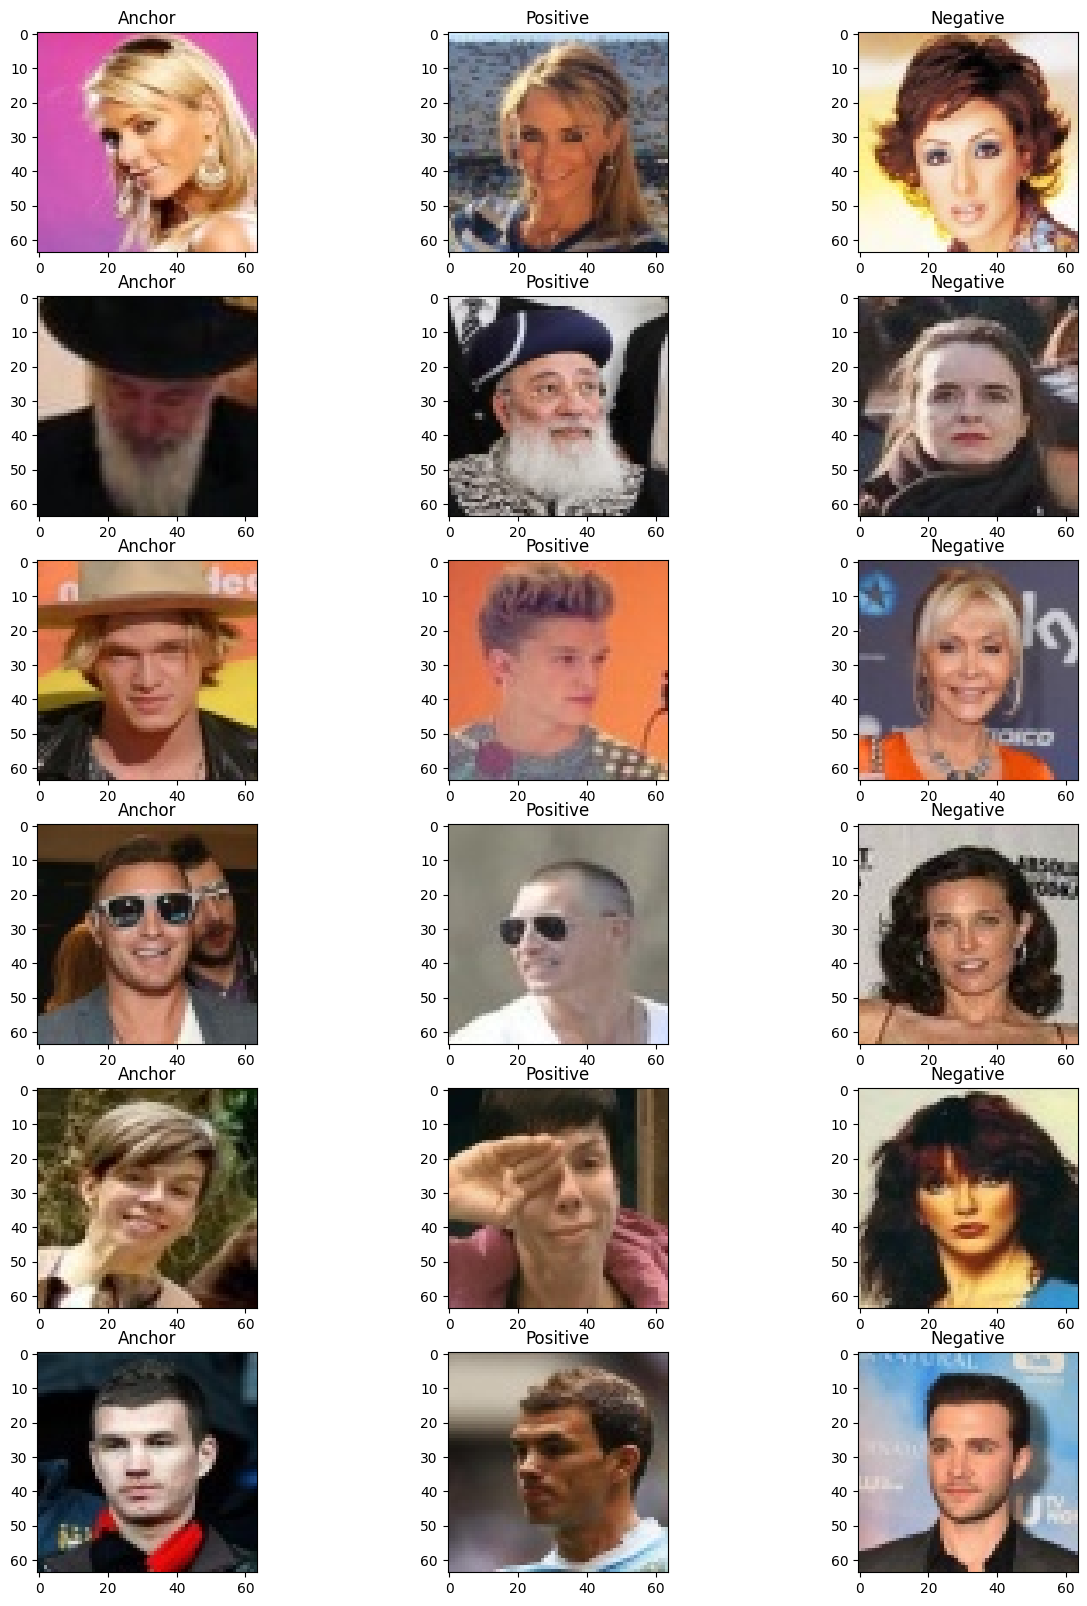

In [9]:
train_dataset = TripletDataset(triplets, batch_size=64)

plot_images = train_dataset.__getitem__(1)
num_plots = 6

f, axes = plt.subplots(num_plots, 3, figsize=(15, 20))
a,p,n = plot_images[0]
for i in range(num_plots):
    axes[i, 0].imshow(a[i])
    axes[i, 0].set_title("Anchor")
    axes[i, 1].imshow(p[i])
    axes[i, 1].set_title("Positive")
    axes[i, 2].imshow(n[i])
    axes[i, 2].set_title("Negative")

In [10]:
encoder = tf.keras.Sequential([

    tf.keras.Input(shape=IMAGE_SHAPE),
    layers.Rescaling(1./255.),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(64, 64, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2), strides=(2,2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2), strides=(2,2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.SpatialDropout2D(0.2),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.SpatialDropout2D(0.2),

    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Lambda(lambda x: tf.math.l2_normalize(x, axis=1))
    
], name = "Encoder")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1753723248.698075      19 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [11]:
class DistanceLayer(layers.Layer):
    # Use Squared Euclidean Distance
    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, positive, negative):
        an_pos_dist = tf.reduce_sum(tf.square(anchor - positive), -1)
        an_neg_dist = tf.reduce_sum(tf.square(anchor - negative), -1)

        an_pos_dist = tf.expand_dims(an_pos_dist, axis=-1)
        an_neg_dist = tf.expand_dims(an_neg_dist, axis=-1)

        return tf.concat([an_pos_dist, an_neg_dist], axis=1)

In [12]:
anchor_input   = layers.Input(shape=IMAGE_SHAPE, name="Anchor_Input")
positive_input = layers.Input(shape=IMAGE_SHAPE, name="Positive_Input")
negative_input = layers.Input(shape=IMAGE_SHAPE, name="Negative_Input")

embedded_an = encoder(anchor_input)
embedded_pos = encoder(positive_input)
embedded_neg = encoder(negative_input)

distances = DistanceLayer()(
    embedded_an,
    embedded_pos,
    embedded_neg
)

siamese_model = tf.keras.Model(
    inputs  = [anchor_input, positive_input, negative_input],
    outputs = distances,
    name = "Siamese_Network"
)

siamese_model.summary()

Model: "Siamese_Network"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ Anchor_Input        │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Positive_Input      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Negative_Input      │ (None, 64, 64, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Encoder             │ (None, 128)       │  2,015,008 │ Anchor_Input[0][… │
│ (Sequential)        │                   │            │ Positive_Input[0… │
│                     │                   │            │ Negative_Input[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ distance_layer      │ (None, 2)         │          0 │ Encoder[0][0],    │
│ (DistanceLayer)     │                   │            │ Encoder[1][0],    │
│                     │                   │            │ Encoder[2][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,015,008 (7.69 MB)

 Trainable params: 2,011,808 (7.67 MB)

 Non-trainable params: 3,200 (12.50 KB)

In [13]:
def triplet_loss(margin=0.2):
    def compute_loss(y_true, y_pred):
        # Distance between anchor - positive minus Distance between anchor - negative
        an_pos_dist = y_pred[:, 0]
        an_neg_dist = y_pred[:, 1]
        loss = tf.maximum(an_pos_dist - an_neg_dist + margin, 0.0)
        
        return loss
    return compute_loss

In [14]:
siamese_model.compile(
    optimizer = tf.keras.optimizers.Adam(),
    loss = triplet_loss(margin=0.2)
)

In [15]:
%%time
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='loss',
    patience=5,
    min_delta=0.0,
    restore_best_weights = True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath='/kaggle/working/verification_weights.h5',
    monitor='loss',
    save_best_only=True,
    verbose=1
)

EPOCHS = 30

history = siamese_model.fit(train_dataset,
                   epochs=EPOCHS,
                   callbacks=[early_stop, checkpoint])

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()
I0000 00:00:1753723266.689415      62 service.cc:148] XLA service 0x7e847c029210 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753723266.690294      62 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1753723268.587131      62 cuda_dnn.cc:529] Loaded cuDNN version 90300


   2/2812 ━━━━━━━━━━━━━━━━━━━━ 3:14 69ms/step - loss: 0.2473   

I0000 00:00:1753723279.982722      62 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


2812/2812 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.2119
Epoch 1: loss improved from inf to 0.17321, saving model to /kaggle/working/verification_weights.h5
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 209s 64ms/step - loss: 0.2119
Epoch 2/30
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.1091
Epoch 2: loss improved from 0.17321 to 0.09939, saving model to /kaggle/working/verification_weights.h5
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 179s 64ms/step - loss: 0.1091
Epoch 3/30
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0754
Epoch 3: loss improved from 0.09939 to 0.07149, saving model to /kaggle/working/verification_weights.h5
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 180s 64ms/step - loss: 0.0754
Epoch 4/30
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0596
Epoch 4: loss improved from 0.07149 to 0.05806, saving model to /kaggle/working/verification_weights.h5
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 179s 64ms/step - loss: 0.0596
Epoch 5/30
2812/2812 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - loss: 0.0501
Epoch

Text(0.5, 1.0, 'Training Loss')

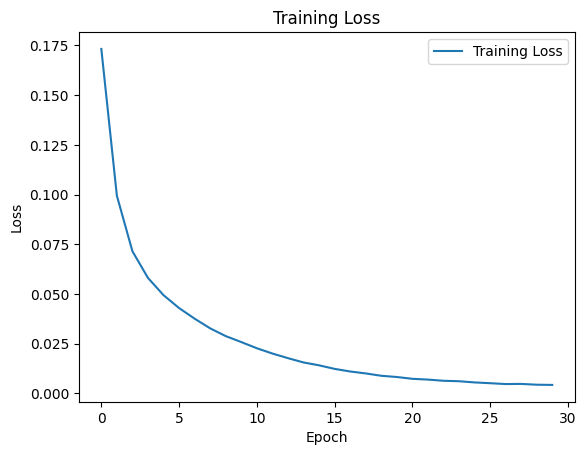

In [16]:
loss = history.history['loss']

plt.plot(loss, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training Loss')

In [17]:
siamese_model.load_weights("/kaggle/working/verification_weights.h5")

In [18]:
val_images_dict = {}
for image, label in zip(verification_images, verification_labels):
    val_images_dict[label] = image

In [19]:
verification_pairs = pd.read_csv('/kaggle/input/verification-pairs/verification_pairs_val.txt', delimiter=' ').to_numpy()

In [20]:
def evaluate_auc(model, verification_pairs, images_dict):
    y_true = []
    y_scores = []
    
    for img1_path, img2_path, label in tqdm(verification_pairs):
        img1 = images_dict[f"./{img1_path}"]
        img1 = np.expand_dims(img1, axis=0)
        
        img2 = images_dict[f"./{img2_path}"]
        img2 = np.expand_dims(img2, axis=0)

        emb1 = model(img1)
        emb2 = model(img2)

        distance = 1 - tf.reduce_sum(tf.square(emb1 - emb2), -1)

        y_true.append(label)
        y_scores.append(distance)


    return np.array(y_true), np.array(y_scores)


In [21]:
y_true, y_scores = evaluate_auc(encoder, verification_pairs, val_images_dict)

100%|██████████| 8804/8804 [10:12<00:00, 14.38it/s]


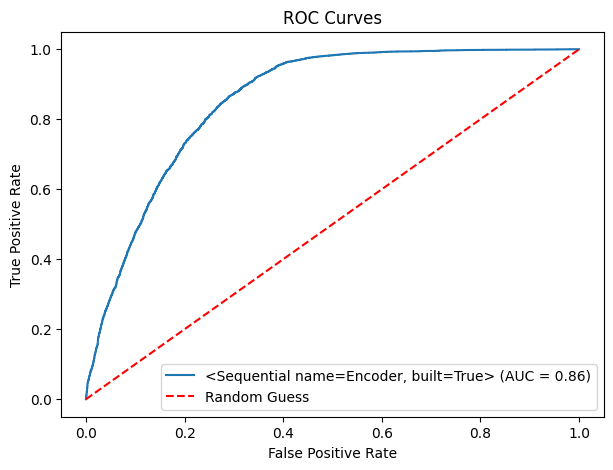

In [22]:
plt.figure(figsize=(7, 5))


fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f'{encoder} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'r--', label='Random Guess')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()

In [23]:
def sample_plot(model, images_dict):
    idx = np.random.randint(len(verification_pairs))
    sample_pair = verification_pairs[idx]
    print(sample_pair)

    img1 = images_dict[f"./{sample_pair[0]}"]
    img1 = np.expand_dims(img1, axis=0)
        
    img2 = images_dict[f"./{sample_pair[1]}"]
    img2 = np.expand_dims(img2, axis=0)

    emb1 = model(img1)
    emb2 = model(img2)

    distance = 1 - tf.reduce_sum(tf.square(emb1 - emb2), -1)

    plt.figure(figsize=(10, 10))
    

    ax = plt.subplot(2, 2, 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(images_dict[f"./{sample_pair[0]}"])
    plt.xlabel(f"{sample_pair[0]}")
    ax.set_title(f"{distance} / {sample_pair[2]}")
    
    ax = plt.subplot(2, 2, 2)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(images_dict[f"./{sample_pair[1]}"])
    plt.xlabel(f"{sample_pair[0]}")

['verification_data/00025259.jpg' 'verification_data/00059799.jpg' 1]


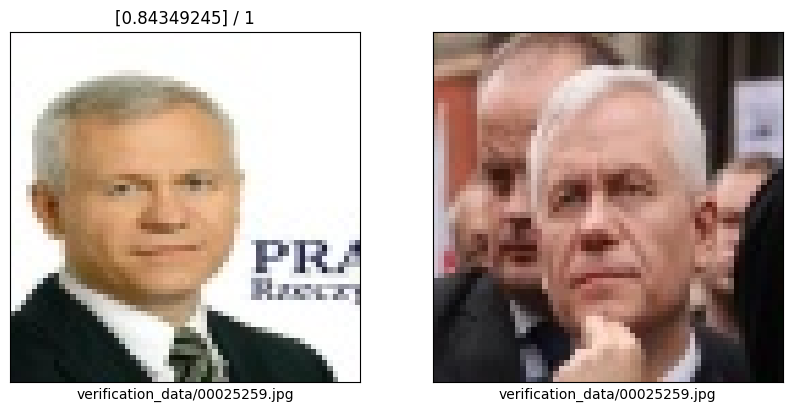

In [24]:
sample_plot(encoder, val_images_dict)